In [108]:
import pandas as pd
import numpy as np

# ------------------------
# Load
# ------------------------

dataset = "MIMIC"
if dataset == "INA":
    filename = "data/dataset_14_04_26_EN_newicd_ccs.json"
    df = pd.read_json(filename)
    disease_mapper = dict(zip(
        list(df["base_pathology_area"].unique()),
        ["SCD", "CHA", "NHOC", "AS", "AHD", "NTDT", "IM", "TDT", "OD"]
    ))
elif dataset == "MIMIC":
    filename = "data/mimic-iv_asplenic_4133_final.json"
    df = pd.read_json(filename)
    disease_mapper = dict(zip(
        list(df["base_pathology_area"].unique()),
        ["OD", "CHA", "SP", "THA", "AHD", "SCD"]
    ))
else:
    raise Exception("wrong dataset!")

df_orig = df.copy()
fig_dir = "figures_final"

df.replace(disease_mapper, inplace=True)
df.replace({"is_alive?": {"n/a": "YES"}}, inplace=True)

df["dead"] = df["is_alive?"].eq("NO")
df["splen"] = df["is_splenectomized?"].eq("YES")
df["nosplen"] = df["is_splenectomized?"].ne("YES")

summary = (
    df.groupby("base_pathology_area")
    .agg(
        Total=("base_pathology_area", "size"),

        Splen=("splen", "sum"),
        NoSplen=("nosplen", "sum"),

        SplenDeath=("dead", lambda x: (x & df.loc[x.index, "splen"]).sum()),
        NoSplenDeath=("dead", lambda x: (x & df.loc[x.index, "nosplen"]).sum()),

        Male=("gender", lambda x: x.eq("M").sum()),
        Female=("gender", lambda x: x.eq("F").sum()),

        MaleDeath=("dead", lambda x: (x & df.loc[x.index, "gender"].eq("M")).sum()),
        FemaleDeath=("dead", lambda x: (x & df.loc[x.index, "gender"].eq("F")).sum()),

        TotalDeaths=("dead", "sum")
    )
    .reset_index()
    .rename(columns={"base_pathology_area": "Disease"})
)

summary["MortSplen"] = summary["SplenDeath"] / summary["Splen"].replace(0, np.nan) * 100
summary["MortNoSplen"] = summary["NoSplenDeath"] / summary["NoSplen"].replace(0, np.nan) * 100

summary["MortMale"] = (
    summary["MaleDeath"] /
    summary["Male"].replace(0, np.nan) * 100
)

summary["MortFemale"] = (
    summary["FemaleDeath"] /
    summary["Female"].replace(0, np.nan) * 100
)

summary["Mortality"] = (
    summary["TotalDeaths"] /
    summary["Total"] * 100
)

summary = summary.sort_values("Total", ascending=False)
summary

,Disease,Total,Splen,NoSplen,SplenDeath,NoSplenDeath,Male,Female,MaleDeath,FemaleDeath,TotalDeaths,MortSplen,MortNoSplen,MortMale,MortFemale,Mortality
2,OD,2686,623,2063,59,328,1498,1188,221,166,387,9.470305,15.899176,14.753004,13.973064,14.408042
1,CHA,770,7,763,2,149,392,378,80,71,151,28.571429,19.528178,20.408163,18.783069,19.610390
4,SP,256,256,0,24,0,109,147,12,12,24,9.375000,NaN,11.009174,8.163265,9.375000
0,AHD,218,0,218,0,19,70,148,6,13,19,NaN,8.715596,8.571429,8.783784,8.715596
5,THA,186,1,185,0,12,72,114,3,9,12,0.000000,6.486486,4.166667,7.894737,6.451613
3,SCD,17,0,17,0,2,7,10,1,1,2,NaN,11.764706,14.285714,10.000000,11.764706


<Figure size 640x480 with 0 Axes>

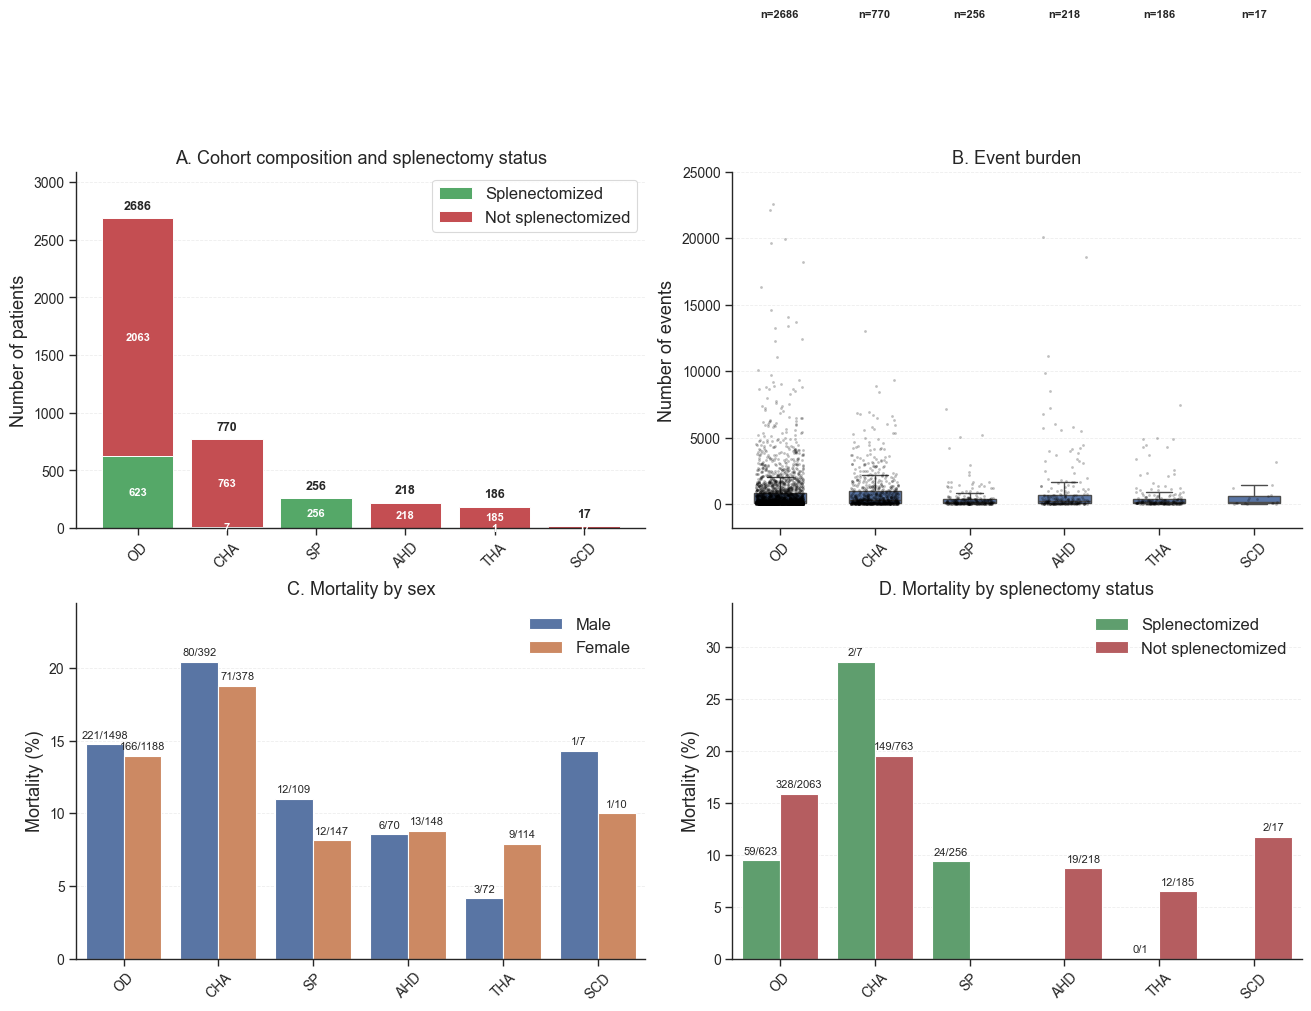

In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = summary.copy()

palette = {
    "Male": "#4C72B0",
    "Female": "#DD8452",
    "Splenectomized": "#55A868",
    "Not splenectomized": "#C44E52"
}
sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.35
)

sns.despine()


fig, axs = plt.subplots(
    2,2,
    figsize=(13,10),
    constrained_layout=True
)


# -------------------------
# PANEL A
# Cohort composition + splenectomy status
# -------------------------

tmp = summary.sort_values("Total", ascending=False).copy()

axs[0,0].bar(
    tmp["Disease"],
    tmp["Splen"],
    color=palette["Splenectomized"],
    edgecolor="white",
    linewidth=0.7,
    label="Splenectomized"
)

axs[0,0].bar(
    tmp["Disease"],
    tmp["NoSplen"],
    bottom=tmp["Splen"],
    color=palette["Not splenectomized"],
    edgecolor="white",
    linewidth=0.7,
    label="Not splenectomized"
)

# segment labels + total labels
for i, row in enumerate(tmp.itertuples()):

    if row.Splen > 0:
        axs[0,0].text(
            i,
            row.Splen / 2,
            f"{int(row.Splen)}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold"
        )

    if row.NoSplen > 0:
        axs[0,0].text(
            i,
            row.Splen + row.NoSplen / 2,
            f"{int(row.NoSplen)}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold"
        )

    axs[0,0].text(
        i,
        row.Total + tmp["Total"].max() * 0.02,
        f"{int(row.Total)}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

axs[0,0].set_title("A. Cohort composition and splenectomy status")
axs[0,0].set_xlabel("")
axs[0,0].set_ylabel("Number of patients")
axs[0,0].tick_params(axis="x", rotation=45)

axs[0,0].set_ylim(
    0,
    tmp["Total"].max() * 1.15
)

axs[0,0].legend(
    title="",
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.85
)

axs[0,0].grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

axs[0,0].grid(axis="x", visible=False)
axs[0,0].set_axisbelow(True)



# -------------------------
# PANEL B
# Event burden
# -------------------------

tmp = df_orig.copy()

tmp["event_length"] = tmp["events"].apply(len)

tmp = tmp.dropna(
    subset=["base_pathology_area", "event_length"]
)

# Usa il mapping solo se serve
if disease_mapper is not None:
    tmp["base_pathology_area"] = tmp["base_pathology_area"].map(disease_mapper)

order = summary["Disease"].tolist()

sns.boxplot(
    data=tmp,
    x="base_pathology_area",
    y="event_length",
    order=order,
    color=palette["Male"],
    width=0.55,
    showfliers=False,
    ax=axs[0,1]
)

sns.stripplot(
    data=tmp,
    x="base_pathology_area",
    y="event_length",
    order=order,
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25,
    ax=axs[0,1]
)

axs[0,1].set_title("B. Event burden")
axs[0,1].set_xlabel("")
axs[0,1].set_ylabel("Number of events")
axs[0,1].tick_params(axis="x", rotation=45)

axs[0,1].grid(axis="y", linestyle="--", alpha=0.35)
axs[0,1].grid(axis="x", visible=False)
axs[0,1].set_axisbelow(True)

# Counts above each boxplot
counts = (
    tmp["base_pathology_area"]
    .value_counts()
    .reindex(order)
    .fillna(0)
    .astype(int)
)

#ylim = axs[0,1].get_ylim()[1]
ymin, _ = axs[0,1].get_ylim()
axs[0,1].set_ylim(ymin, 25000)

for i, disease in enumerate(order):
    axs[0,1].text(
        i,
        ylim * 0.98,
        f"n={counts[disease]}",
        ha="center",
        va="top",
        fontsize=8,
        fontweight="bold"
    )

sns.despine(ax=axs[0,1])


# -------------------------
# PANEL C
# Mortality by sex
# -------------------------

sex_long = pd.melt(
    summary,
    id_vars=["Disease", "Male", "Female", "MaleDeath", "FemaleDeath"],
    value_vars=["MortMale", "MortFemale"],
    var_name="Group",
    value_name="MortalityRate"
)

sex_long["Group"] = sex_long["Group"].replace({
    "MortMale": "Male",
    "MortFemale": "Female"
})

sns.barplot(
    data=sex_long,
    x="Disease",
    y="MortalityRate",
    hue="Group",
    ax=axs[1,0],
    palette=palette
)

axs[1,0].set_title("C. Mortality by sex")
axs[1,0].set_xlabel("")
axs[1,0].set_ylabel("Mortality (%)")
axs[1,0].tick_params(axis="x", rotation=45)
axs[1,0].legend(title="", frameon=False)

# ---------- labels ----------

labels = []

for _, row in summary.iterrows():

    labels.append(f"{int(row['MaleDeath'])}/{int(row['Male'])}")

for _, row in summary.iterrows():

    labels.append(f"{int(row['FemaleDeath'])}/{int(row['Female'])}")

k = 0

for container in axs[1,0].containers:

    texts = labels[k:k+len(container)]

    axs[1,0].bar_label(
        container,
        labels=texts,
        padding=3,
        fontsize=8
    )

    k += len(container)

axs[1,0].set_ylim(
    0,
    max(sex_long["MortalityRate"])*1.20
)

# -------------------------
# PANEL D
# Mortality by splenectomy
# -------------------------

long = pd.melt(
    summary,
    id_vars=[
        "Disease",
        "Splen",
        "NoSplen",
        "SplenDeath",
        "NoSplenDeath"
    ],
    value_vars=[
        "MortSplen",
        "MortNoSplen"
    ],
    var_name="Group",
    value_name="MortalityRate"
)

long["Group"] = long["Group"].replace({
    "MortSplen": "Splenectomized",
    "MortNoSplen": "Not splenectomized"
})

sns.barplot(
    data=long,
    x="Disease",
    y="MortalityRate",
    hue="Group",
    ax=axs[1,1],
    palette=palette
)

axs[1,1].set_title("D. Mortality by splenectomy status")
axs[1,1].set_xlabel("")
axs[1,1].set_ylabel("Mortality (%)")
axs[1,1].tick_params(axis="x", rotation=45)
axs[1,1].legend(title="", frameon=False)

# ---------- labels ----------

labels = []

for _, row in summary.iterrows():

    if not(row["Splen"] == 0 or row["Splen"] == np.nan):
        labels.append(f"{int(row['SplenDeath'])}/{int(row['Splen'])}")

for _, row in summary.iterrows():

    if not(row["NoSplen"] == 0 or row["NoSplen"] == np.nan):
        labels.append(f"{int(row['NoSplenDeath'])}/{int(row['NoSplen'])}")

k = 0

for container in axs[1,1].containers:

    texts = labels[k:k+len(container)]

    axs[1,1].bar_label(
        container,
        labels=texts,
        padding=3,
        fontsize=8
    )

    k += len(container)

axs[1,1].set_ylim(
    0,
    max(long["MortalityRate"])*1.20
)
for ax in axs.flat:

    sns.despine(ax=ax)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )

    ax.grid(axis="x", visible=False)

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.set_axisbelow(True)

fig.savefig(f"{fig_dir}/{dataset}_distrib.png")

In [116]:
ylim

37997.3

In [110]:
summary["Disease"].astype(str).tolist()

['OD', 'CHA', 'SP', 'AHD', 'THA', 'SCD']

In [111]:
summary

,Disease,Total,Splen,NoSplen,SplenDeath,NoSplenDeath,Male,Female,MaleDeath,FemaleDeath,TotalDeaths,MortSplen,MortNoSplen,MortMale,MortFemale,Mortality
2,OD,2686,623,2063,59,328,1498,1188,221,166,387,9.470305,15.899176,14.753004,13.973064,14.408042
1,CHA,770,7,763,2,149,392,378,80,71,151,28.571429,19.528178,20.408163,18.783069,19.610390
4,SP,256,256,0,24,0,109,147,12,12,24,9.375000,NaN,11.009174,8.163265,9.375000
0,AHD,218,0,218,0,19,70,148,6,13,19,NaN,8.715596,8.571429,8.783784,8.715596
5,THA,186,1,185,0,12,72,114,3,9,12,0.000000,6.486486,4.166667,7.894737,6.451613
3,SCD,17,0,17,0,2,7,10,1,1,2,NaN,11.764706,14.285714,10.000000,11.764706


In [112]:
labels, texts

(['59/623',
  '2/7',
  '24/256',
  '0/1',
  '328/2063',
  '149/763',
  '19/218',
  '12/185',
  '2/17'],
 ['328/2063', '149/763', '19/218', '12/185', '2/17'])

In [113]:
len(axs[1,0].containers[1])

6